<a href="https://colab.research.google.com/github/snehakodavanti-droid5/AIML---Training/blob/main/AIML_Module_01_Lab_01_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extracting features from data

Module 1, Lab 1<br>



In [ ]:
! pip install wikipedia

import wikipedia
import nltk
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import re
import unicodedata
import plotly.express as px
import pandas as pd

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=462464cfc7d5d4f62d17aa99025775b4a59f40b44410d1a3655fa5733d1fb953
  Stored in directory: /root/.cache/pip/wheels/63/47/7c/a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
Successfully built wikipedia


# Part 1: Features of text
How do we apply machine learning on text? We can't directly use the text as input to our algorithms. We need to convert them to features. In this notebook, we will explore a simple way of converting text to features.

Let us download a few documents off Wikipedia.

In [ ]:
# ---------- English Topics ----------
topic1 = 'Penguin'
topic2 = 'Dolphin'

wikipedia.set_lang('en')

eng1 = wikipedia.page(topic1).content
eng2 = wikipedia.page(topic2).content


# ----- Penguin Article -----
print(topic1, "Article:")
print(eng1[:100])

print("Length of article:", len(eng1))

print("Does the word 'Penguin' appear in article?", "Penguin" in eng1)

text1 = eng1.lower()
print("Lowercase text sample:")
print(text1[:100])

print("\n")


# ----- Dolphin Article -----
print(topic2, "Article:")
print(eng2[:100])

print("Length of article:", len(eng2))

print("Does the word 'Dolphin' appear in article?", "Dolphin" in eng2)

text2 = eng2.lower()
print("Lowercase text sample:")
print(text2[:100])

print("\n")


# ---------- Hindi Topics ----------
topic1 = 'पेंगुइन'
topic2 = 'डॉल्फ़िन'

wikipedia.set_lang('hi')

hin1 = wikipedia.page(wikipedia.search(topic1)[0]).content
hin2 = wikipedia.page(wikipedia.search(topic2)[0]).content


print(topic1, "Article:")
print(hin1[:120])

print("\n")

print(topic2, "Article:")
print(hin2[:120])

Penguin Article:
Penguins are a group of flightless semi-aquatic sea birds which live almost exclusively in the South
Length of article: 30110
Does the word 'Penguin' appear in article? True
Lowercase text sample:
penguins are a group of flightless semi-aquatic sea birds which live almost exclusively in the south


Dolphin Article:
A dolphin is any one of the 40 extant species of aquatic mammal from the cetacean families Delphinid
Length of article: 60475
Does the word 'Dolphin' appear in article? True
Lowercase text sample:
a dolphin is any one of the 40 extant species of aquatic mammal from the cetacean families delphinid


पेंगुइन Article:
पेंगुइन (पीढ़ी स्फेनिस्कीफोर्मेस, प्रजाति स्फेनिस्कीडाई) जलीय समूह के उड़ने में असमर्थ पक्षी हैं जो केवल दक्षिणी गोलार्द


डॉल्फ़िन Article:
सूंस (डॉल्फिन) समुद्री स्तनधारी जीव हैं और तिमि तथा शिंशुमार के निकट संबंधी हैं। इनके १७ वंश और ४० प्रजातियां हैं। इनका 


This is what the text looks like:

In [ ]:
hin2

'सूंस (डॉल्फिन) समुद्री स्तनधारी जीव हैं और तिमि तथा शिंशुमार के निकट संबंधी हैं। इनके १७ वंश और ४० प्रजातियां हैं। इनका आकार १.२ मी (४ फीट) एवं ४०० कि.ग्रा (माउई सूंस) से लेकर ९.५ मी (३० फीट) १० टन (ऑर्का या किलर व्हेल) तक हो सकता है। ये विश्व भर में पाई जाती हैं, खास तौर पर महाद्वीपीय जलसीमा के उथले सागरीय क्षेत्रों में। ये मांसाहारी होती हैं और छोटी मछलियों और विद्रूपों को खाती हैं। सीटेसियन गण में डेल्फिनिडि सबसे बड़ा और अपेक्षाकृत नन कुल है। सूंसो का प्रादुर्भाव पृथ्वी पर लगभग १ करोड़ वर्ष पहले मियोसीन काल के दौरान हुआ था। सूंस पृथ्वी के कुछ सबसे अधिक बुद्धिमान जीवों में से एक है और उनके अक्सर दोस्ताना व्यवहार और हमेशा खुश रहने की आदत ने उन्हें मानवो के बीच खासा लोकप्रिय बना दिया है। गंगा नदी में पायी जाने वाली सूंस को भारत सरकार ने भारत का राष्ट्रीय जलीय जीव घोषित किया है।\n\n\n== शब्द-साधन ==\nनाम मूल रूप से ग्रीक δελφίς (डेल्फी), "डॉल्फ़िन" से है, जो ग्रीक theλ Greek (डेल्फ़स), "गर्भ" से संबंधित था। इसलिए जानवर के नाम की व्याख्या "गर्भ के साथ एक मछली" के रूप में की जा सकती है। 

We need to clean this up a bit. Let us remove all the special characters and keep only 26 letters and space. Note that this will remove accented characters in hindi also. We are also removing all the numbers and spaces. So this is not an ideal solution.

In [ ]:
def cleanup(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

In [ ]:
eng1 = cleanup(eng1)
eng2 = cleanup(eng2)
hin1 = cleanup(hin1)
hin2 = cleanup(hin2)

In [ ]:
print(eng1)
print(eng2)
print(hin1)
print(hin2)


penguins are a group of flightless semiaquatic sea birds which live almost exclusively in the southern hemisphere only one species the galapagos penguin lives at and slightly north of the equator highly adapted for life in the ocean water penguins have countershaded dark and white plumage and flippers for swimming most penguins feed on krill fish squid and other forms of sea life which they catch with their bills and swallow whole while swimming a penguin has a spiny tongue and powerful jaws to grip slippery prey
they spend about half of their lives on land and the other half in the sea the largest living species is the emperor penguin aptenodytes forsteri on average adults are about 11 m 3 ft 7 in tall and weigh 35 kg 77 lb the smallest penguin species is the little blue penguin eudyptula minor also known as the fairy penguin which stands around 3033 cm 1213 in tall and weighs 1213 kg 2629 lb today larger penguins generally inhabit colder regions and smaller penguins inhabit regions w

Now let us calculate the frequency of the character n-grams. N-grams are groups of characters of size n. A unigram is a single character and a bigram is a group of two characters and so on.

Let us count the frequency of each character in a text and plot it in a histogram.

In [ ]:
# convert a tuple of characters to a string
def tuple2string(tup):
  st = ''
  for ii in tup:
    st = st + ii
  return st

# convert a tuple of tuples to a list of strings
def key2string(keys):
  return [tuple2string(i) for i in keys]

# plot the histogram
def plothistogram(ngram):
  keys = key2string(ngram.keys())
  values = list(ngram.values())

  # sort the keys in alphabetic order
  combined = zip(keys, values)
  zipped_sorted = sorted(combined, key=lambda x: x[0])
  keys, values = map(list, zip(*zipped_sorted))
  plt.bar(keys, values)

Let us compare the histograms of English pages and Hindi pages. Can you spot a difference?

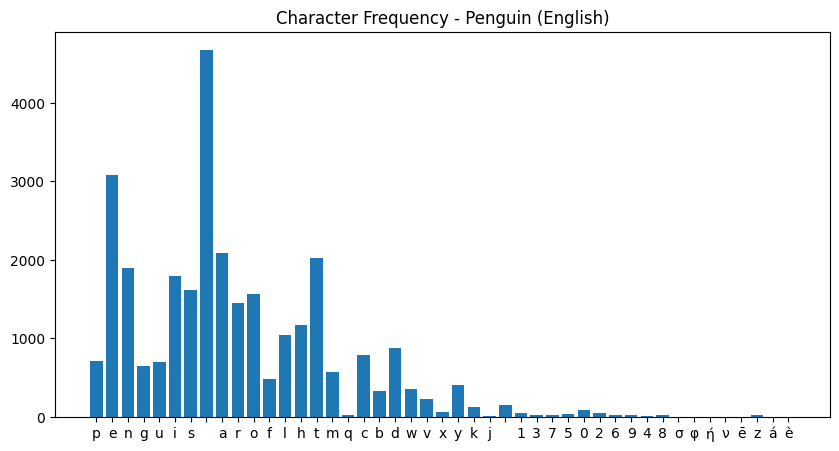

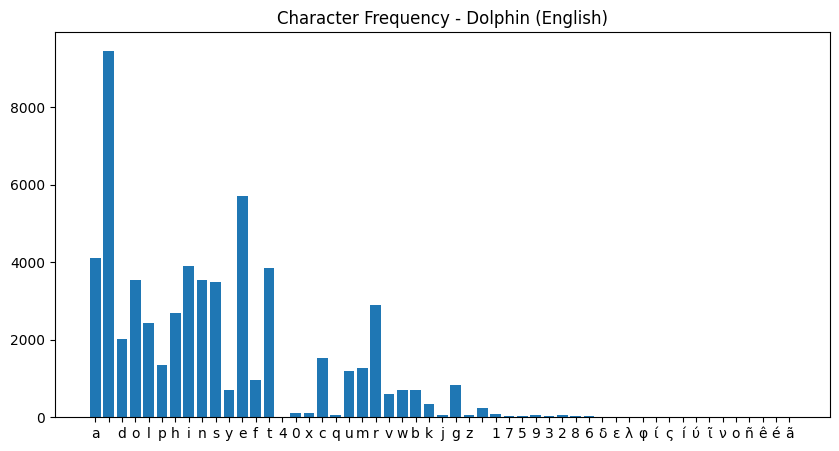

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# Penguin (English 1)
freq_eng1 = Counter(eng1)

plt.figure(figsize=(10,5))
plt.bar(freq_eng1.keys(), freq_eng1.values())
plt.title("Character Frequency - Penguin (English)")
plt.show()


# Dolphin (English 2)
freq_eng2 = Counter(eng2)

plt.figure(figsize=(10,5))
plt.bar(freq_eng2.keys(), freq_eng2.values())
plt.title("Character Frequency - Dolphin (English)")
plt.show()

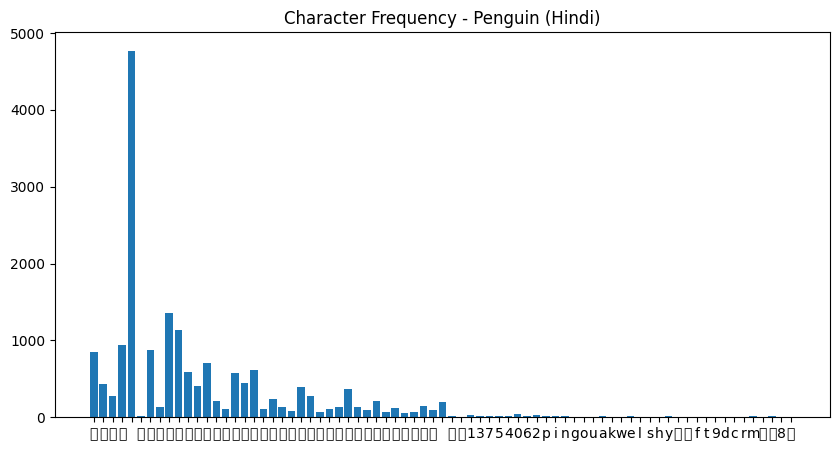

In [ ]:
freq_hin1 = Counter(hin1)

plt.figure(figsize=(10,5))
plt.bar(freq_hin1.keys(), freq_hin1.values())
plt.title("Character Frequency - Penguin (Hindi)")
plt.show()

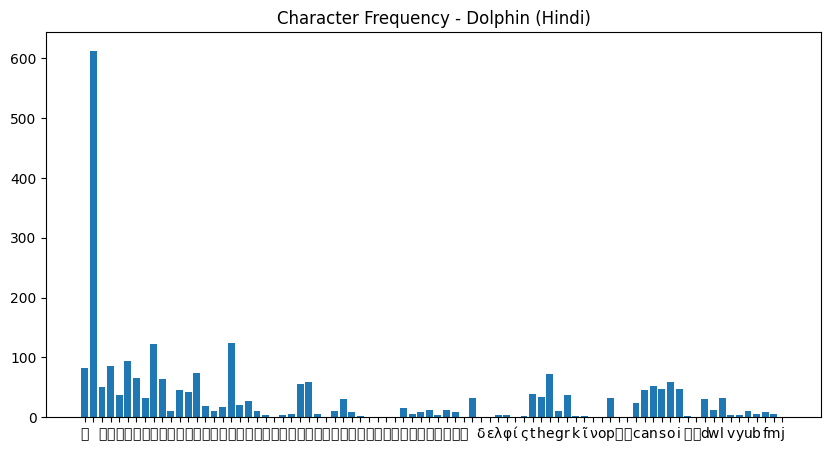

In [ ]:
freq_hin2 = Counter(hin2)

plt.figure(figsize=(10,5))
plt.bar(freq_hin2.keys(), freq_hin2.values())
plt.title("Character Frequency - Dolphin (Hindi)")
plt.show()

From the histograms, we can see that the frequency of letters varies across the texts. In the English text, letters like e, a, and t appear more frequently than other letters. In the Hindi text, characters such as क, ा, and र appear more frequently compared to others.

However, it is still difficult to clearly distinguish between the two languages using only unigrams, since some character frequencies may overlap

We can see that the unigrams for Hindi and English are very similar. So this is not a good feature if we want to distinguish between English and Hindi. Let us look at bigrams.

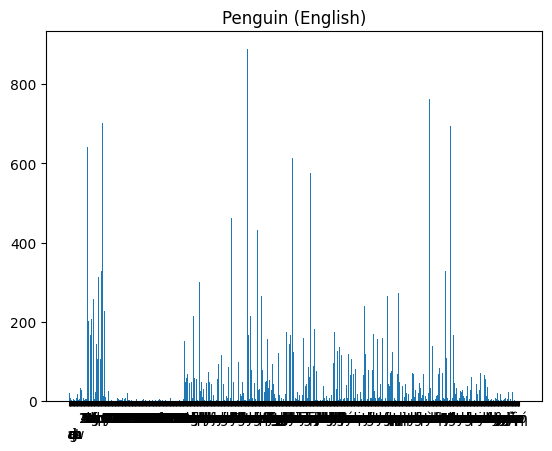

In [ ]:
bigram_eng1 = Counter(ngrams(eng1,2))
plothistogram(bigram_eng1)
plt.title('Penguin (English)')
plt.show()

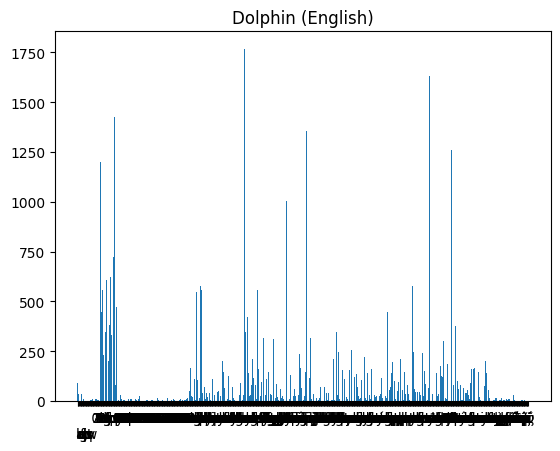

In [ ]:
bigram_eng2 = Counter(ngrams(eng2,2))
plothistogram(bigram_eng2)
plt.title('Dolphin (English)')
plt.show()

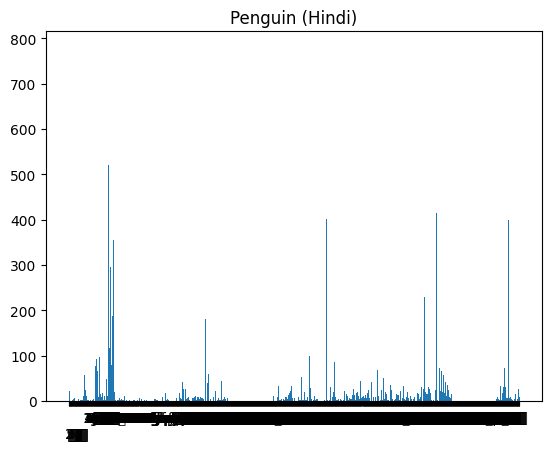

In [ ]:
bigram_hin1 = Counter(ngrams(hin1,2))
plothistogram(bigram_hin1)
plt.title('Penguin (Hindi)')
plt.show()

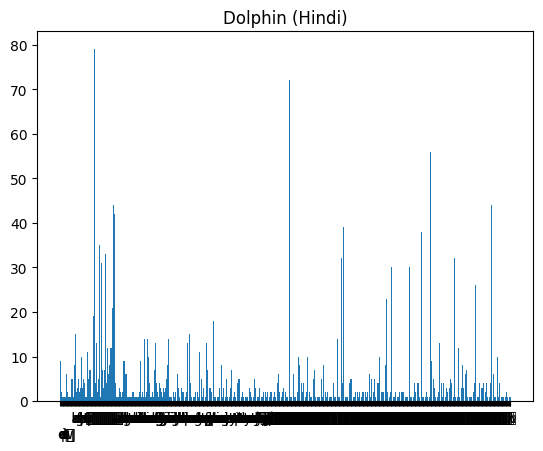

In [ ]:
bigram_hin2 = Counter(ngrams(hin2,2))
plothistogram(bigram_hin2)
plt.title('Dolphin (Hindi)')
plt.show()

Another way to visualize bigrams is to use a 2-dimensional graph.

In [ ]:
def plotbihistogram(ngram):
  freq = np.zeros((26,26))
  for ii in range(26):
    for jj in range(26):
      freq[ii,jj] = ngram[(chr(ord('a')+ii), chr(ord('a')+jj))]
  plt.imshow(freq, cmap = 'jet')
  return freq

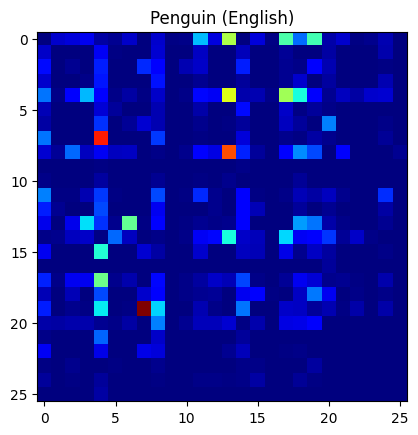

In [ ]:
bigram_eng1 = Counter(ngrams(eng1,2))
plotbihistogram(bigram_eng1)
plt.title("Penguin (English)")
plt.show()

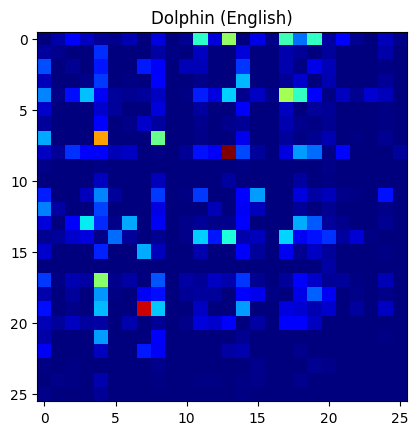

In [ ]:
bigram_eng2 = Counter(ngrams(eng2,2))
plotbihistogram(bigram_eng2)
plt.title("Dolphin (English)")
plt.show()

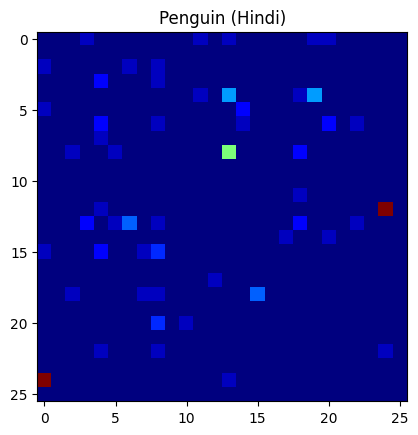

In [25]:
bigram_hin1 = Counter(ngrams(hin1,2))
plotbihistogram(bigram_hin1)
plt.title("Penguin (Hindi)")
plt.show()

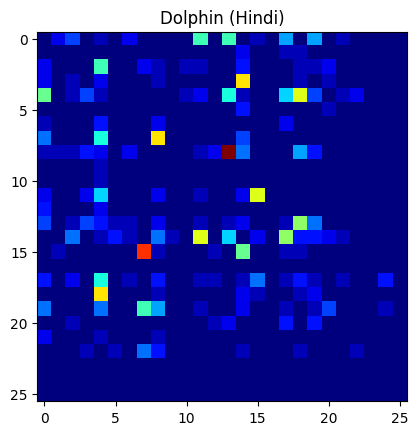

In [26]:
bigram_hin2 = Counter(ngrams(hin2,2))
plotbihistogram(bigram_hin2)
plt.title("Dolphin (Hindi)")
plt.show()

Let us look at the top 10 ngrams for each text.

In [ ]:
from IPython.core.debugger import set_trace

def ind2tup(ind):
  ind = int(ind)
  i = int(ind/26)
  j = int(ind%26)
  return (chr(ord('a')+i), chr(ord('a')+j))

def ShowTopN(bifreq, n=10):
  f = bifreq.flatten()
  arg = np.argsort(-f)
  for ii in range(n):
    print(f'{ind2tup(arg[ii])} : {f[arg[ii]]}')

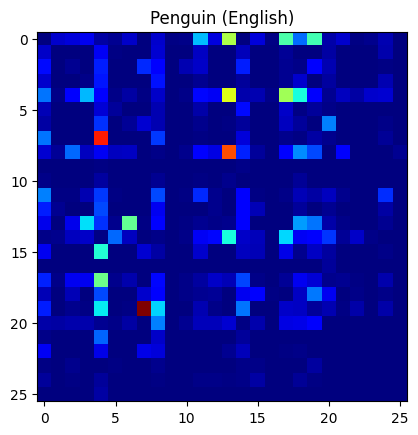

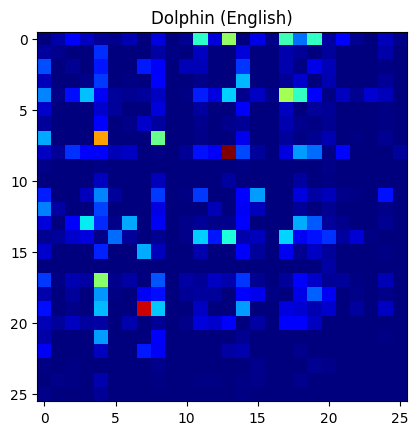

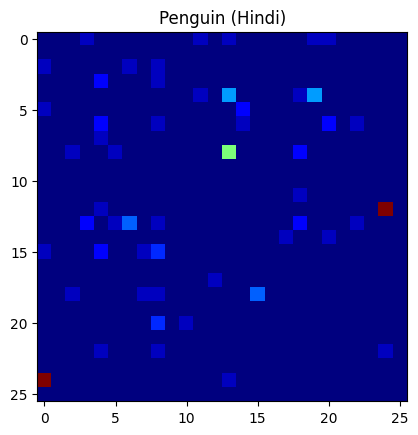

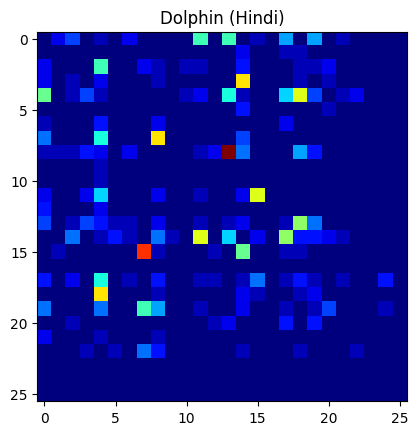

In [27]:
bieng1 = plotbihistogram(bigram_eng1)
plt.title("Penguin (English)")
plt.show()

bieng2 = plotbihistogram(bigram_eng2)
plt.title("Dolphin (English)")
plt.show()

bihin1 = plotbihistogram(bigram_hin1)
plt.title("Penguin (Hindi)")
plt.show()

bihin2 = plotbihistogram(bigram_hin2)
plt.title("Dolphin (Hindi)")
plt.show()

In [30]:
def ShowTopN(freq, N=10):
    flat = freq.flatten()
    top_indices = flat.argsort()[-N:][::-1]

    for idx in top_indices:
        i = idx // freq.shape[1]
        j = idx % freq.shape[1]
        print(chr(ord('a')+i) + chr(ord('a')+j), ":", flat[idx])

In [31]:
print('\nPenguin (English):')
ShowTopN(bieng1)

print('\nDolphin (English):')
ShowTopN(bieng2)

print('\nPenguin (Hindi):')
ShowTopN(bihin1)

print('\nDolphin (Hindi):')
ShowTopN(bihin2)


Penguin (English):
th : 695.0
he : 612.0
in : 575.0
en : 431.0
an : 389.0
er : 379.0
re : 334.0
ng : 327.0
ar : 309.0
at : 301.0

Dolphin (English):
in : 1354.0
th : 1261.0
he : 1002.0
er : 743.0
an : 719.0
re : 700.0
hi : 649.0
ar : 577.0
at : 559.0
es : 556.0

Penguin (Hindi):
ya : 18.0
my : 18.0
in : 9.0
en : 5.0
et : 5.0
sp : 4.0
ng : 4.0
pi : 3.0
ui : 3.0
ge : 2.0

Dolphin (Hindi):
in : 21.0
ph : 18.0
do : 14.0
hi : 14.0
se : 14.0
ol : 13.0
es : 13.0
lp : 13.0
ns : 11.0
or : 11.0


We observe that the bigram patterns for the texts “Penguin” and “Dolphin” are quite similar because both texts are written in the same language (English). Therefore, bigram frequencies do not strongly distinguish between topics when the language is the same.

However, bigram frequencies are generally useful for distinguishing between different languages, since each language tends to have characteristic combinations of characters.

Thus, we were able to convert a many-dimensional input (the text) into numerical features such as 26 dimensions for unigrams and 26 × 26 dimensions for bigrams, which can be used as inputs for machine learning models.




# Part 2: Written numbers

We will use a subset of the MNIST dataset. Each input character is represented in a 28*28 array. Let us see if we can extract some simple features from these images which can help us distinguish between the digits.

Load the dataset:

In [32]:
from keras.datasets import mnist

#loading the dataset
(train_X, train_y), (test_X, test_y) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Extract a subset of the data for our experiment:

In [36]:
no2 = train_X[train_y==2,:,:]
no7 = train_X[train_y==7,:,:]

Let us visualize a few images here:

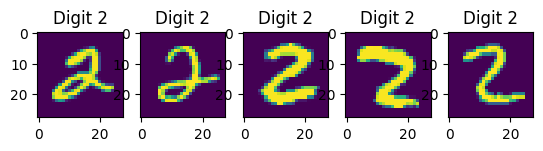

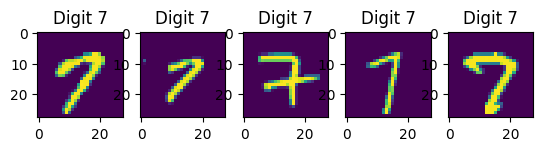

In [37]:
for ii in range(5):
  plt.subplot(1, 5, ii+1)
  plt.imshow(no2[ii,:,:])
  plt.title("Digit 2")
plt.show()

for ii in range(5):
  plt.subplot(1, 5, ii+1)
  plt.imshow(no7[ii,:,:])
  plt.title("Digit 7")
plt.show()

suNow, let us start with a simple feature: the sum of all pixels and see how good this feature is.

In [38]:
sum2 = np.sum(no2 > 0, (1,2))  # threshold before adding up
sum7 = np.sum(no7 > 0, (1,2))

Let us visualize how good this feature is: (X-axis is mean, y-axis is the digit)

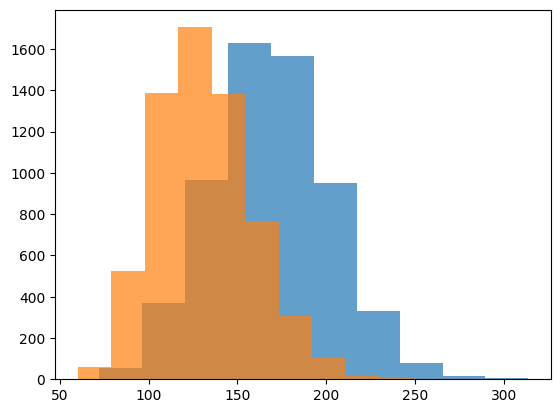

In [39]:
plt.hist(sum2, alpha=0.7);
plt.hist(sum7, alpha=0.7);

We can already see that this feature separates the two classes quite well.

Let us look at another, more complicated feature. We will count the number black pixels that are surrounded on four sides by non-black pixels, or "hole pixels".

In [40]:
def cumArray(img):
  img2 = img.copy()
  for ii in range(1, img2.shape[1]):
    img2[ii,:] = img2[ii,:] + img2[ii-1,:]  # for every row, add up all the rows above it.
  img2 = img2>0
  return img2

def getHolePixels(img):
  im1 = cumArray(img)
  im2 = np.rot90(cumArray(np.rot90(img)), 3) # rotate and cumulate it again for differnt direction
  im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
  im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
  hull =  im1 & im2 & im3 & im4 # this will create a binary image with all the holes filled in.
  hole = hull & ~ (img>0) # remove the original digit to leave behind the holes
  return hole

Visualize a few:

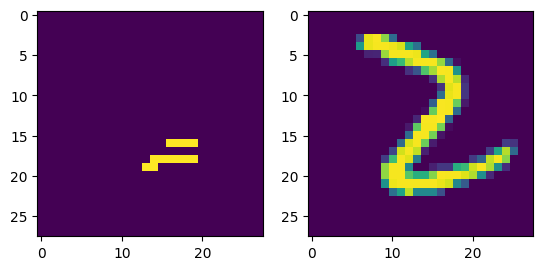

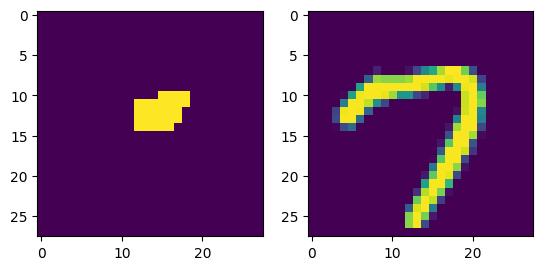

In [41]:
imgs = [no2[456,:,:], no7[456,:,:]]

for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getHolePixels(img))

  plt.subplot(1,2,2)
  plt.imshow(img)

  plt.show()

Now let us plot the number of hole pixels and see how this feature behaves

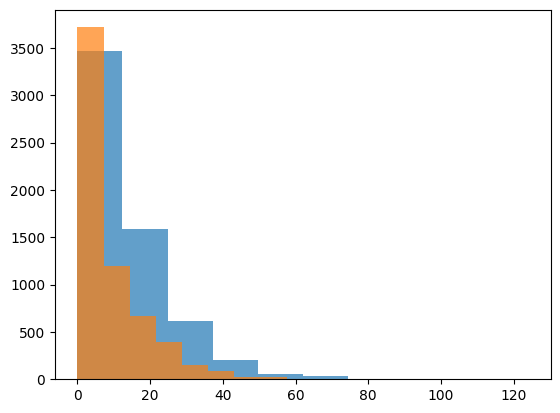

In [42]:
hole2 = np.array([getHolePixels(i).sum() for i in no2])
hole7 = np.array([getHolePixels(i).sum() for i in no7])

plt.hist(hole2, alpha=0.7)
plt.hist(hole7, alpha=0.7)
plt.show()


Now let us try the number of pixels in the 'hull' or the number with the holes filled in:

In [44]:
def getHullPixels(img):
  im1 = cumArray(img)
  im2 = np.rot90(cumArray(np.rot90(img)), 3) # rotate and cumulate it again for differnt direction
  im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
  im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
  hull =  im1 & im2 & im3 & im4 # this will create a binary image with all the holes filled in.
  return hull

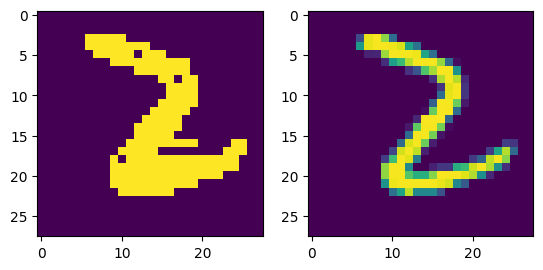

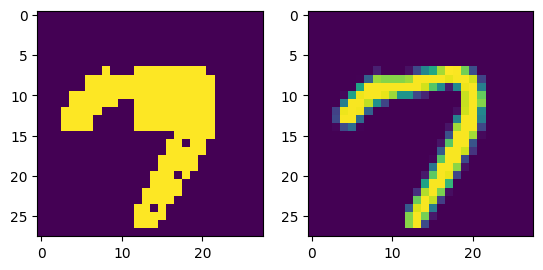

In [45]:
imgs = [no2[456,:,:], no7[456,:,:]]

for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getHullPixels(img))

  plt.subplot(1,2,2)
  plt.imshow(img)

  plt.show()

Plotting the number of hull pixels versus the digit:

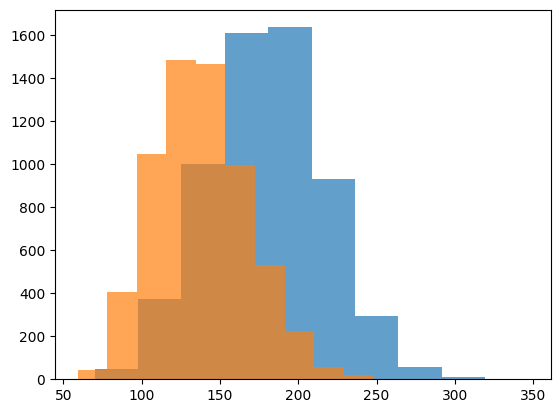

In [46]:
hull2 = np.array([getHullPixels(i).sum() for i in no2])
hull7 = np.array([getHullPixels(i).sum() for i in no7])

plt.hist(hull2, alpha=0.7)
plt.hist(hull7, alpha=0.7)
plt.show()

Let us try one more feature, where we look at the number of boundary pixels in each image.

In [47]:
def minus(a, b):
  return a & ~ b

def getBoundaryPixels(img):
  img = img.copy()>0  # binarize the image
  rshift = np.roll(img, 1, 1)
  lshift = np.roll(img, -1 ,1)
  ushift = np.roll(img, -1, 0)
  dshift = np.roll(img, 1, 0)
  boundary = minus(img, rshift) | minus(img, lshift) | minus(img, ushift) | minus(img, dshift)
  return boundary

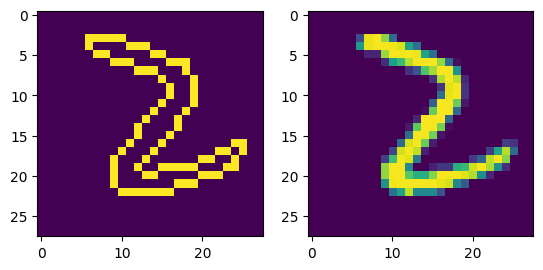

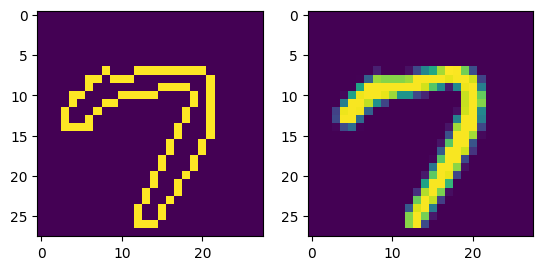

In [48]:
imgs = [no2[456,:,:], no7[456,:,:]]

for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getBoundaryPixels(img))

  plt.subplot(1,2,2)
  plt.imshow(img)

  plt.show()

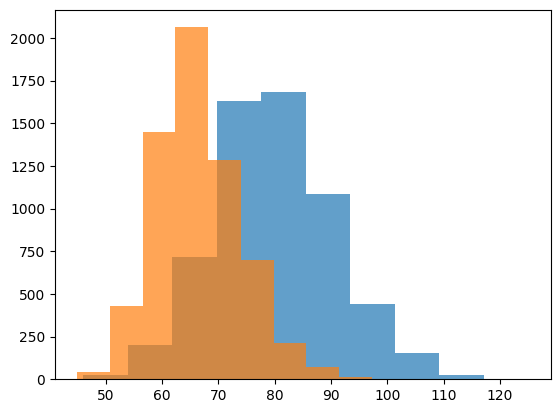

In [49]:
bound2 = np.array([getBoundaryPixels(i).sum() for i in no2])
bound7 = np.array([getBoundaryPixels(i).sum() for i in no7])

plt.hist(bound2, alpha=0.7)
plt.hist(bound7, alpha=0.7)
plt.show()

What will happen if we plot two features together?

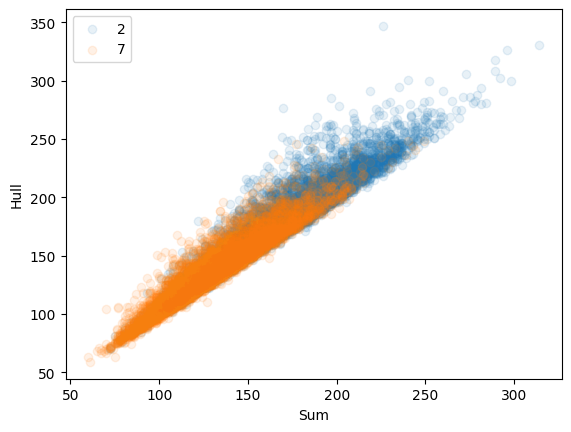

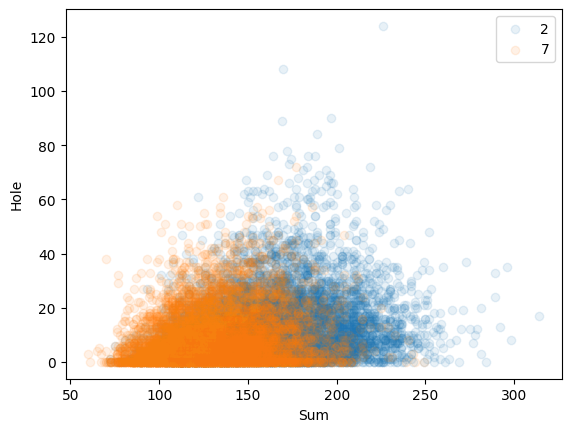

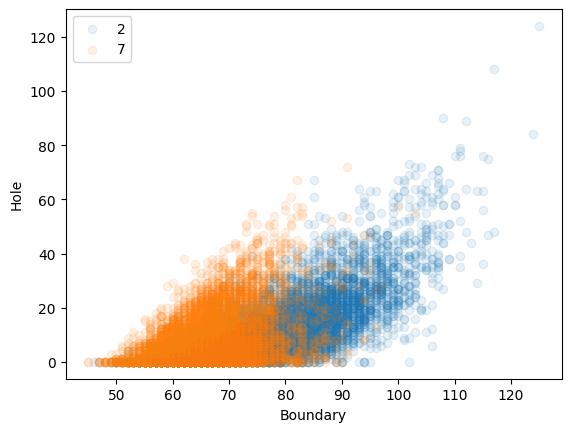

In [50]:
# Sum and hull
plt.scatter(sum2, hull2, alpha=0.1)
plt.scatter(sum7, hull7, alpha=0.1)
plt.xlabel('Sum')
plt.ylabel('Hull')
plt.legend(['2','7'])
plt.show()


# Sum and hole
plt.scatter(sum2, hole2, alpha=0.1)
plt.scatter(sum7, hole7, alpha=0.1)
plt.xlabel('Sum')
plt.ylabel('Hole')
plt.legend(['2','7'])
plt.show()


# Hole and boundary
plt.scatter(bound2, hole2, alpha=0.1)
plt.scatter(bound7, hole7, alpha=0.1)
plt.xlabel('Boundary')
plt.ylabel('Hole')
plt.legend(['2','7'])
plt.show()

Now let us try plotting 3 features together.

In [51]:
cl2 = ['class 2'] * len(sum2)
cl7 = ['class 7'] * len(sum7)

df = pd.DataFrame(list(zip(np.concatenate((hole2, hole7)),
                           np.concatenate((sum2, sum7)),
                           np.concatenate((bound2, bound7)),
                           np.concatenate((cl2, cl7)))),
                  columns=['Hole', 'Sum', 'Boundary', 'Class'])

df.head()

fig = px.scatter_3d(df, x='Hole', y='Sum', z='Boundary', color='Class', opacity=0.1)
fig.show()

Feel free to explore the above graph with your mouse.


We have seen that we extracted four features from a 28*28 dimensional image.


Some questions to explore:
1. Which is the best combination of features?
A good combination is Sum, Boundary, and Hole because they capture the size and shape of the digit and help separate classes.
2. How would you test or visualize four or more features?
We can use multiple scatter plots to visualize higher-dimensional data.
3. Can you come up with your own features?
Possible features can be stroke thickness, center of mass.
4. Will these features work for different classes other than 0 and 1?
These features may work, but some digits have similar shapes, so additional features may be needed.
5. What will happen if we take more that two classes at a time?
The feature space becomes more complex and classes may overlap, making classification harder.